In [ ]:
# Global Oil and Gas Exposure Study
# 00: PopExposure Set Up

# This file sets up environment to apply Popexposure to finds the number of people living near buffered oil and gas wells. 
# Author: Lara Schwarz
# Last updated: September 2025

# Steps included in this script:

## Set up step 1: Importing libraries
## Set up step 2: Defining the environments
## Set up step 3: Loading global social data 

In [9]:
## Set up step 1: Importing libraries

import geopandas as gpd
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
from thefuzz import process
import pandas as pd
import pathlib
import pandas as pd
import sys
import os
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd
from rasterio.plot import show
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import fiona
import geopandas as gpd
from shapely.geometry import Polygon
import ee
import geemap
import matplotlib.cm as cm
import matplotlib.colors as colors
from shapely.geometry import box
import math
from shapely.geometry import Point
import glob
import seaborn as sns
import openpyxl
import subprocess
from pathlib import Path
from popexposure import PopEstimator

In [10]:
## Set up step 2: defining the environments
# Define base paths
repo = pathlib.Path.cwd().parent.parent
share_path = pathlib.Path("/Users/larasch/Library/CloudStorage/OneDrive-SharedLibraries-UW/casey_cohort - Documents/data")

# Define code path and add to sys.path
code_path = repo / "code"

# Define data paths
# location of the oil and gas data
oil_path = share_path / "environmental/oil_and_gas/raw_data/ogim.parquet"

# location of the adminstrative boundary shapefile
countries_path = share_path / "geo_boundaries/processed_data/country_admin/country_geom_filtered.parquet"

# location of the population data
ghs_pop_path = share_path / "social_including_census/raw_data/GHS_POP_E2020_GLOBE_R2023A_54009_100_V1_0/GHS_POP_E2020_GLOBE_R2023A_54009_100_V1_0.tif"

# Import local modules
from popexposure import *

CSV loaded successfully with encoding ISO-8859-1.
   year country_location_name admin1_location_name admin2_location_name  \
0  2019           Afghanistan           Badakhshan       Shahr-e-Buzorg   
1  2019           Afghanistan           Badakhshan             Shighnan   
2  2019           Afghanistan           Badakhshan                Zebak   
3  2019           Afghanistan           Badakhshan               Wakhan   
4  2019           Afghanistan           Badakhshan      Koran wa Monjan   

   loc_id  pop_masking_flag  LDIpc_mean  LDIpc_lower  LDIpc_upper  
0   93247                 0       801.0        442.0       1393.0  
1   93248                 0      1327.0        599.0       2405.0  
2   93249                 0       798.0        431.0       1375.0  
3   93250                 0      1019.0        491.0       1870.0  
4   93251                 0       800.0        438.0       1399.0  


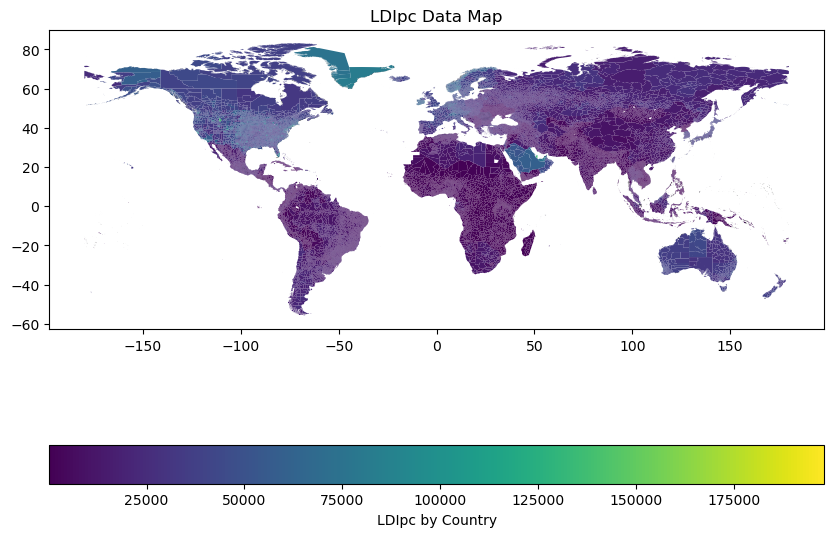

<Axes: >

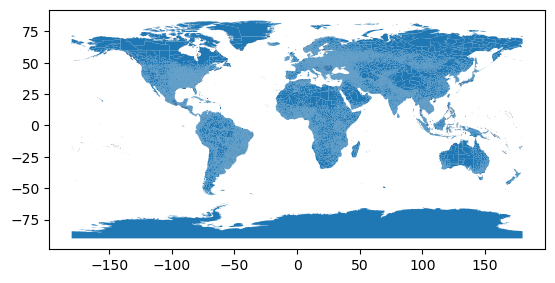

In [11]:
## Set up step 3: Loading global social data 
## Importing global country shapefiles 

# Define the paths
csv_path = repo / "data/IHME_LSAE_admin2_LDIpc_2019_with_loc_id(in)_v2.csv"  # Adjust the path accordingly

# Load the CSV data
# Try reading the CSV with a different encoding (ISO-8859-1 or utf-16)
try:
    csv_data = pd.read_csv(csv_path, encoding='ISO-8859-1')  # or try encoding='utf-16'
    print("CSV loaded successfully with encoding ISO-8859-1.")
except UnicodeDecodeError:
    print("Error: Unable to decode CSV with the provided encoding.")

# Check the first few rows of the CSV
print(csv_data.head())

# Load the shapefile (GeoDataFrame)
shapefile_path = repo/ "data/OneDrive_1_12-11-2024/lbd_standard_admin_2.shp"

global_shapefiles = gpd.read_file(shapefile_path)

# merge the data
merged_shapefile_social = global_shapefiles.merge(csv_data, how='left', left_on='loc_id', right_on='loc_id')

# Now you can plot the data on the map
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
merged_shapefile_social.plot(column='LDIpc_mean', ax=ax, legend=True,
                legend_kwds={'label': "LDIpc by Country",
                             'orientation': "horizontal"})
plt.title("LDIpc Data Map")
plt.show()

global_shapefiles.plot()
